In [1]:
## 1. Import Libraries & Load Dataset

import pandas as pd

file_path = input("Enter CSV file path/name: ")
df = pd.read_csv(file_path)

Enter CSV file path/name:  insurance.csv


In [2]:
## 2. Statistical Summary (describe)

df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [3]:
## 3. Dataset Overview (rows, columns, missing, duplicates, memory)

info = pd.DataFrame({
    "property": ["Rows", "Columns", "Missing values", "Duplicates", "Memory usages"],
    "Values": [
        df.shape[0],
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        f"{round(df.memory_usage(deep=True).sum()/1024**2, 2)} MB"
    ]
})
display(info)

,property,Values
0,Rows,1338
1,Columns,7
2,Missing values,0
3,Duplicates,1
4,Memory usages,0.28 MB


In [4]:
## 4. Column Type Detection (Numerical / Categorical / Boolean / Datetime


numerical = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical = df.select_dtypes(include=['object', 'string']).columns.tolist()   # 'string' dtype bhi cover
boolean = df.select_dtypes(include=['bool']).columns.tolist()
datetime_cols = df.select_dtypes(include=['datetime']).columns.tolist()

print("Numerical Columns"); print("-----------------")
for col in numerical: print(col)
print()

print("Categorical Columns"); print("-------------------")
for col in categorical: print(col)
print()

print("Boolean Columns"); print("----------------")
for col in boolean: print(col)
print()

print("Datetime Columns"); print("----------------")
for col in datetime_cols: print(col)

Numerical Columns
-----------------
age
bmi
children
charges

Categorical Columns
-------------------
sex
smoker
region

Boolean Columns
----------------

Datetime Columns
----------------


In [5]:
## 5. Detailed Feature-wise Summary Statistics

summary = df.describe().T.round(2)
display(summary)

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.21,14.05,18.00,27.00,39.00,51.00,64.00
bmi,1338.0,30.66,6.10,15.96,26.30,30.40,34.69,53.13
children,1338.0,1.09,1.21,0.00,0.00,1.00,2.00,5.00
charges,1338.0,13270.42,12110.01,1121.87,4740.29,9382.03,16639.91,63770.43


In [6]:
## 6. Missing Value Report

missing = pd.DataFrame({
    "columns": df.columns,
    "missing values": df.isnull().sum().values
})
missing["percentage"] = (missing["missing values"] / len(df)) * 100
display(missing)

,columns,missing values,percentage
0,age,0,0.0
1,sex,0,0.0
2,bmi,0,0.0
3,children,0,0.0
4,smoker,0,0.0
5,region,0,0.0
6,charges,0,0.0


In [7]:
## 7. Duplicate Rows Report

duplicate_values = df.duplicated().sum()
duplicate_percentage = (duplicate_values / len(df)) * 100
print("Duplicate Report"); print("-"*30)
print(f"Duplicate Rows : {duplicate_values}")
print(f"Percentage     : {round(duplicate_percentage,2)} %")

Duplicate Report
------------------------------
Duplicate Rows : 1
Percentage     : 0.07 %


In [8]:
## 8. Column Reference List

col = pd.DataFrame({"columns": df.columns})
display(col)

,columns
0,age
1,sex
2,bmi
3,children
4,smoker
5,region
6,charges


In [9]:
## 9. Numerical Features Subset

numerical_df = df[numerical]
display(numerical_df)

,age,bmi,children,charges
0,19,27.900,0,16884.92400
1,18,33.770,1,1725.55230
2,28,33.000,3,4449.46200
3,33,22.705,0,21984.47061
4,32,28.880,0,3866.85520
...,...,...,...,...
1333,50,30.970,3,10600.54830
1334,18,31.920,0,2205.98080
1335,18,36.850,0,1629.83350
1336,21,25.800,0,2007.94500


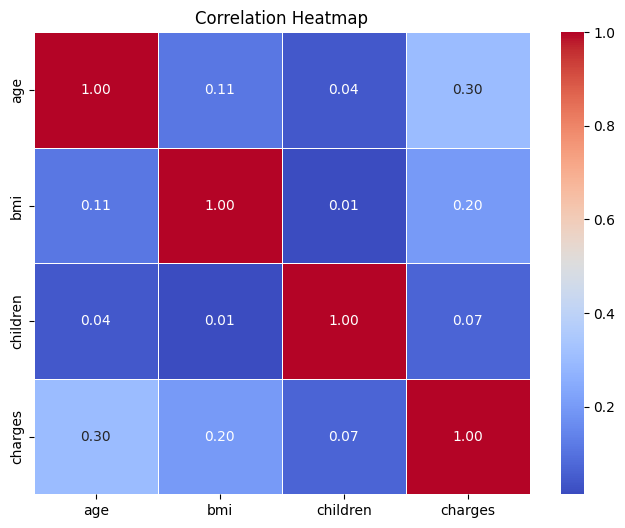

In [10]:
## 10. Correlation Heatmap

import seaborn as sns
import matplotlib.pyplot as plt

matrix = numerical_df.corr()
plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [11]:
## 11. Column Index Table (for Target Selection)

col_drop = pd.DataFrame({
    "Index": range(1, len(df.columns)+1),
    "Column Name": df.columns
})

In [17]:
## 12. Target Selection, Validation & Automatic Feature Cleaning

while True:
    display(col_drop)
    user_input = int(input("Enter Target Column Number: "))
    result = col_drop[col_drop["Index"] == user_input]

    if result.empty:
        print("❌ Invalid column number. Please try again.\n")
        continue

    target_name = result["Column Name"].iloc[0]
    target_dtype = df[target_name].dtype
    unique_count = df[target_name].nunique()
    unique_ratio = unique_count / len(df)

    is_numeric_target = pd.api.types.is_numeric_dtype(df[target_name])
    is_text_type = not is_numeric_target

    if unique_ratio > 0.90:
        print("\n❌ Invalid Target Selected")
        print("Reason : Almost every value is unique (unsuitable as target).\n")
        continue

    problem_type = "Classification" if (is_text_type or unique_ratio <= 0.05) else "Regression"

    print(f"\nSelected Target  : {target_name}")
    print(f"Target Data Type : {target_dtype}")
    print(f"Unique Values    : {unique_count}")
    print(f"Unique Ratio     : {unique_ratio:.2%}")
    print(f"\n✅ Detected Problem : {problem_type}")
    break

# target select hote hi x,y turant bante hain — kabhi stale nahi honge
x = df.drop(target_name, axis=1)
y = df[target_name]

if y.isnull().sum() > 0:
    print(f"Dropping {y.isnull().sum()} rows with missing target values  as NAN values are present")
    valid_idx = y.notnull()
    x = x[valid_idx]
    y = y[valid_idx]


# datetime columns -> numeric features
datetime_cols = x.select_dtypes(include=["datetime"]).columns.tolist()
for col in datetime_cols:
    x[col] = pd.to_datetime(x[col])
    x[col + "_year"] = x[col].dt.year
    x[col + "_month"] = x[col].dt.month
    x[col + "_day"] = x[col].dt.day
    x = x.drop(col, axis=1)

numerical = x.select_dtypes(include=["number"]).columns.tolist()
categorical = x.select_dtypes(include=["object", "string"]).columns.tolist()

# fully-null columns drop (warna median/mode crash karega)
fully_null = [c for c in x.columns if x[c].isnull().all()]
if fully_null:
    print("Dropping fully-null columns:", fully_null)
    x = x.drop(columns=fully_null)
    numerical = [c for c in numerical if c not in fully_null]
    categorical = [c for c in categorical if c not in fully_null]

# high-cardinality columns drop (jaise Name, Ticket)
high_cardinality = [c for c in categorical if x[c].nunique() / len(x) > 0.9]
if high_cardinality:
    print("Dropping high-cardinality columns:", high_cardinality)
    x = x.drop(columns=high_cardinality)
    categorical = [c for c in categorical if c not in high_cardinality]

print("\nFinal Numerical Columns  :", numerical)
print("Final Categorical Columns:", categorical)

,Index,Column Name
0,1,age
1,2,sex
2,3,bmi
3,4,children
4,5,smoker
5,6,region
6,7,charges


Enter Target Column Number:  4



Selected Target  : children
Target Data Type : int64
Unique Values    : 6
Unique Ratio     : 0.45%

✅ Detected Problem : Classification

Final Numerical Columns  : ['age', 'bmi', 'charges']
Final Categorical Columns: ['sex', 'smoker', 'region']


PHASE 2 : PREPROCESSING


In [18]:
## 13.Handle Missing Values (Feature Columns)

total_missing = x.isnull().sum().sum()

if total_missing == 0:
    print("No missing value in dataset")
else:
    for col in numerical:
        if x[col].isnull().sum() > 0:
            x[col] = x[col].fillna(x[col].median())
    for col in categorical:
        if x[col].isnull().sum() > 0:
            x[col] = x[col].fillna(x[col].mode().iloc[0])

print(x.isnull().sum())
print(x.isnull().sum().sum())

No missing value in dataset
age        0
sex        0
bmi        0
smoker     0
region     0
charges    0
dtype: int64
0


In [19]:
## 14  Encoding Strategy Check

if len(categorical) > 0:
    print(len(categorical))
    print("Encoding Method: One Hot Encoding")
else:
    print("No Categorical Columns Found")
    print("Encoding Skipped")

3
Encoding Method: One Hot Encoding


In [20]:
## 17. Train-Test Split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [21]:
## 18. One-Hot Encoding (Categorical Features)

x_train = pd.get_dummies(x_train, columns=categorical)
x_test = pd.get_dummies(x_test, columns=categorical)

x_train, x_test = x_train.align(x_test, join="left", axis=1, fill_value=0)

SCALING

In [22]:
## 19 Standardize Numerical Features (StandardScaler)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

MODEL TRAINING


In [23]:
## 20. Define Classification Models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

classification_models = {
    "Logistic Regression": {"model": LogisticRegression(), "scaled": True},
    "Decision Tree": {"model": DecisionTreeClassifier(), "scaled": False},
    "Random Forest": {"model": RandomForestClassifier(), "scaled": False},
    "KNN": {"model": KNeighborsClassifier(), "scaled": True},
    "SVC": {"model": SVC(), "scaled": True}
}

In [24]:
## 21. Define Regression Models

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

regression_models = {
    "Linear Regression": {"model": LinearRegression(), "scaled": True},
    "Decision Tree": {"model": DecisionTreeRegressor(), "scaled": False},
    "Random Forest": {"model": RandomForestRegressor(), "scaled": False},
    "KNN": {"model": KNeighborsRegressor(), "scaled": True},
    "SVR": {"model": SVR(), "scaled": True}
}

In [25]:
## 22. Select Model Set Based on Detected Problem Type

if problem_type == "Classification":
    models = classification_models
elif problem_type == "Regression":
    models = regression_models

In [26]:
## 23. Train & Evaluate All Model

from sklearn.metrics import accuracy_score, r2_score

results = {}
trained_models = {}

for name, info in models.items():
    model = info["model"]
    scaled = info["scaled"]

    if scaled:
        model.fit(x_train_scaled, y_train)
        predictions = model.predict(x_test_scaled)
    else:
        model.fit(x_train, y_train)
        predictions = model.predict(x_test)

    score = accuracy_score(y_test, predictions) if problem_type == "Classification" else r2_score(y_test, predictions)

    results[name] = score
    trained_models[name] = score

In [27]:
## 24. Identify Best Performing Model

best_model = max(results, key=results.get)
best_score = results[best_model]

print("Best Model:", best_model)
print("Best_Score:", best_score)

Best Model: Decision Tree
Best_Score: 0.503731343283582


In [30]:
## 25. Final Results Summary (All Models)

print(trained_models)

{'Linear Regression': 0.7511263149200413, 'Decision Tree': 0.6821695992430998, 'Random Forest': 0.7024285398335598, 'KNN': -0.1971386828609083, 'SVR': -0.15858741332067017}
